In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:

import os
import numpy as np
import cv2
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, 
    MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, 
    Dense, Dropout, ZeroPadding2D, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD

2026-04-17 11:37:53.365880: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776425873.554882      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776425873.608247      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776425874.021883      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776425874.021918      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776425874.021921      55 computation_placer.cc:177] computation placer alr

In [2]:
import os
import numpy as np
import cv2
import random
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import img_to_array

def load_data(base_path):
    data = []
    labels = []
    
    categories = sorted(os.listdir(base_path)) 
    print(f"Categorias encontradas: {categories}")
    
    for category in categories:
        path = os.path.join(base_path, category)
        if not os.path.isdir(path): 
            continue
        
        print(f"Carregando imagens de: {category}...")
        
        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                image = cv2.imread(img_path)
                
                # --- MELHORIA PARA RAIO-X (CLAHE) ---
                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
                image = clahe.apply(image)
                image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB) # DenseNet exige 3 canais
                # ------------------------------------
                
                image = cv2.resize(image, (224, 224))
                image = img_to_array(image)
                data.append(image)
                labels.append(category)
            except Exception as e:
                # Pula arquivos que não sejam imagens (ex: .DS_Store ou corrompidos)
                continue
                
    # Normalização e conversão para arrays numpy
    data = np.array(data, dtype="float32") / 255.0
    labels = np.array(labels)
    
    # Transforma nomes (Strings) em vetores numéricos One-Hot
    mlb = LabelBinarizer()
    labels = mlb.fit_transform(labels)
    
    print(f"Total de imagens carregadas: {len(data)}")
    return data, labels

from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

#train_path = "/kaggle/input/datasets/jppb2005/test-pneumo/Dataset/train"
#test_path = "/kaggle/input/datasets/jppb2005/test-pneumo/Dataset/test"

train_path = "/kaggle/input/datasets/mos3santos/imagens-de-radiografia-de-trax-pneumonia/chest_xray/train"
test_path = "/kaggle/input/datasets/mos3santos/imagens-de-radiografia-de-trax-pneumonia/chest_xray/test"
val_path = "/kaggle/input/datasets/mos3santos/imagens-de-radiografia-de-trax-pneumonia/chest_xray/val"

# Carregamento
X_train_full, Y_train_full = load_data(train_path)
X_test, Y_test = load_data(test_path)
X_valid, Y_valid = load_data(val_path)

## Criando a Validação (20% do treino)
#(X_train, X_valid, Y_train, Y_valid) = train_test_split(
#    X_train_full, Y_train_full, test_size=0.20, random_state=42
#)

# Se o seu Y_train tem apenas uma coluna (shape N, 1), vamos forçar para 2 colunas
if Y_train_full.shape[1] == 1:
    # Isso transforma [0, 1, 0] em [[1,0], [0,1], [1,0]]
    Y_train_full = to_categorical(Y_train_full, num_classes=2)
    Y_test = to_categorical(Y_test, num_classes=2)
    Y_valid = to_categorical(Y_valid, num_classes=2)

# Redivida ou atualize as variáveis se necessário
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train_full, Y_train_full, test_size=0.2, random_state=42)


print("Estrutura final dos dados:")
print(f"Treino: {X_train.shape}")
print(f"Validação: {X_valid.shape}")
print(f"Teste: {X_test.shape}")

Categorias encontradas: ['NORMAL', 'PNEUMONIA']
Carregando imagens de: NORMAL...
Carregando imagens de: PNEUMONIA...
Total de imagens carregadas: 5216
Categorias encontradas: ['NORMAL', 'PNEUMONIA']
Carregando imagens de: NORMAL...
Carregando imagens de: PNEUMONIA...
Total de imagens carregadas: 624
Categorias encontradas: ['NORMAL', 'PNEUMONIA']
Carregando imagens de: NORMAL...
Carregando imagens de: PNEUMONIA...
Total de imagens carregadas: 16
Estrutura final dos dados:
Treino: (4172, 224, 224, 3)
Validação: (1044, 224, 224, 3)
Teste: (624, 224, 224, 3)


# Carregamento de modelo para teste

In [10]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model_path = "/kaggle/input/models/jppb2005/radiografiaanalisev2/keras/default/1/bestmodel.keras"

model = load_model(model_path)

I0000 00:00:1776426219.613350      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776426219.619364      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Matriz de confusão, Precisão, recall e mAp

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score

# 1. Obter as predições para o conjunto de teste
ypred_probs = model.predict(X_test)
ypred_classes = np.argmax(ypred_probs, axis=1)
ytrue_classes = np.argmax(Y_test, axis=1)

labels = ['NORMAL', 'PNEUMONIA']

# 2. Gerar Matriz de Confusão
cm = confusion_matrix(ytrue_classes, ypred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão: Detecção de Pneumonia')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

# 3. Relatório de Precisão, Recall e F1-Score
report = classification_report(ytrue_classes, ypred_classes, target_names=labels)
print("Relatório de Classificação:\n")
print(report)

In [ ]:
# 4. Cálculo do mAP (Average Precision médio)
ap_scores = []
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    # Calcula precisão e recall para cada classe
    precision, recall, _ = precision_recall_curve(Y_test[:, i], ypred_probs[:, i])
    ap = average_precision_score(Y_test[:, i], ypred_probs[:, i])
    ap_scores.append(ap)
    
    plt.plot(recall, precision, label=f'Classe {labels[i]} (AP = {ap:.2f})')

mAP = np.mean(ap_scores)
plt.xlabel('Recall (Sensibilidade)')
plt.ylabel('Precisão')
plt.title(f'Curva Precisão-Recall | mAP Geral: {mAP:.4f}')
plt.legend()
plt.grid(True)
plt.show()

print(f"O mAP (mean Average Precision) do modelo é: {mAP:.4f}")

# Teste de Predição

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


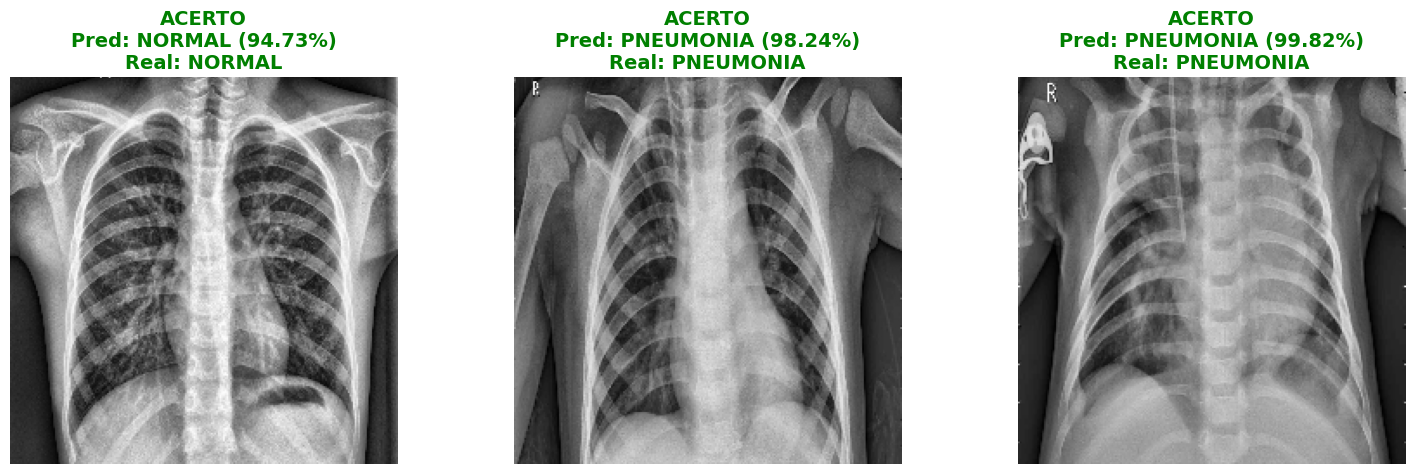

In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt

labels = ['NORMAL', 'PNEUMONIA']
ypred_probs = model.predict(X_test)
ypred_classes = np.argmax(ypred_probs, axis=1)
ytrue_classes = np.argmax(Y_test, axis=1)

total_test_images = len(X_test)
random_indices = random.sample(range(total_test_images), k=3)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)

for n, idx in enumerate(random_indices):
    # Exibe o Raio-X
    ax[n].imshow(X_test[idx])
    
    # Nomes e Confiança
    pred_idx = ypred_classes[idx]
    true_idx = ytrue_classes[idx]
    confianca = ypred_probs[idx][pred_idx] * 100 # Probabilidade da classe escolhida
    
    pred_name = labels[pred_idx]
    true_name = labels[true_idx]
    
    # Lógica de acerto e cor
    is_correct = (pred_idx == true_idx)
    color = 'green' if is_correct else 'red'
    status = "ACERTO" if is_correct else "ERRO"
    
    # Título com Porcentagem de Chance
    ax[n].set_title(f"{status}\nPred: {pred_name} ({confianca:.2f}%)\nReal: {true_name}", 
                    color=color, fontsize=14, fontweight='bold')
    
    ax[n].axis('off')

plt.show()

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. Ajustando os labels para o seu dataset de Raio-X
# Certifique-se de que a ordem aqui é a mesma das suas pastas
labels = ['NORMAL', 'PNEUMONIA']

# 2. Gerando as predições para o conjunto de teste
ypred = model.predict(X_test)

# 3. Identificando acertos e erros para análise
accurate_indices = []
wrong_indices = []

for i in range(len(Y_test)):
    if np.argmax(ypred[i]) == np.argmax(Y_test[i]):
        accurate_indices.append(i)
    else:
        wrong_indices.append(i)

# 4. Escolha o que quer visualizar: accurate_indices ou wrong_indices
# Vamos visualizar 9 erros, que é onde o pesquisador mais aprende sobre o modelo

sample_indices = random.sample(wrong_indices, k=min(9, len(wrong_indices)))

#sample_indices = random.sample(accurate_indices, k=min(9, len(accurate_indices)))

nrows, ncols = 3, 3
fig, ax = plt.subplots(nrows, ncols, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4) # Espaço para ler os títulos

n = 0
for row in range(nrows):
    for col in range(ncols):
        if n < len(sample_indices):
            idx = sample_indices[n]
            
            # Mostra a imagem (X_test)
            ax[row,col].imshow(X_test[idx])
            
            # Pega os nomes das classes
            pred_name = labels[np.argmax(ypred[idx])]
            true_name = labels[np.argmax(Y_test[idx])]
            
            # Define a cor do título: Verde se acertou, Vermelho se errou
            color = 'green' if pred_name == true_name else 'red'
            
            ax[row,col].set_title(f"Pred: {pred_name}\nReal: {true_name}", color=color, fontsize=12)
            ax[row,col].axis('off') # Remove os eixos para focar na imagem
            n += 1

plt.show()